In [1]:
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

## Experiment 1 (fig. 2b)
please run exp/experiment_1.py to generate the pickle files.

dict_keys(['ref_norm_cvs', 'clean_norm_cvs', 'malicious_norm_cvs'])


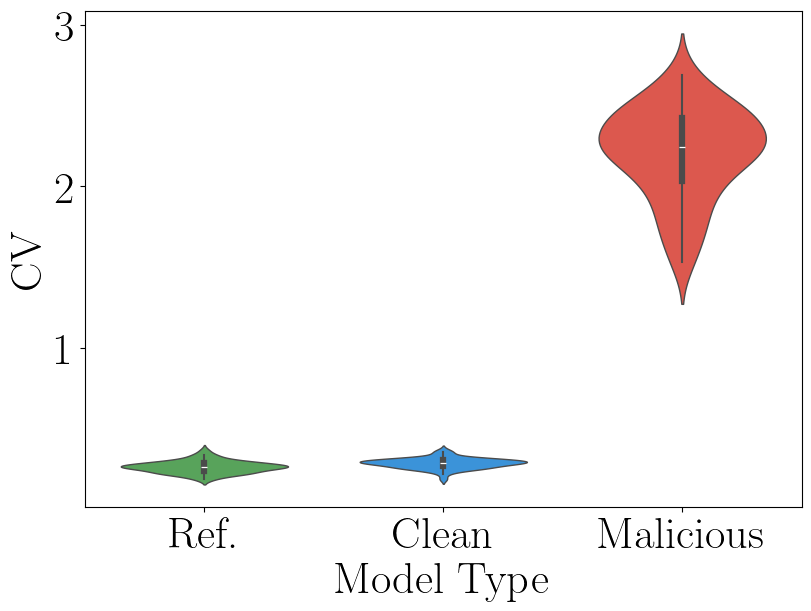

In [2]:
import pickle
from matplotlib import pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import pandas as pd
import numpy as np
fontsize = 32

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "legend.fontsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "text.latex.preamble": r"\usepackage{amsmath}",
})

with open("results/experiment_1.pkl", 'rb') as f:
    results = pickle.load(f)
    
print(results.keys())

reference_norms = results['ref_norm_cvs'][:50]
clean_public_norms = results['clean_norm_cvs'][:50]
malicious_public_norms = results['malicious_norm_cvs'][:50]

seen_examples = len(reference_norms)
data = pd.DataFrame({
    'CV': np.concatenate([reference_norms, clean_public_norms, malicious_public_norms]),
    'Model Type': ['Reference Model'] * seen_examples + ['Clean Global Model'] * seen_examples + ['Malicious Global Model'] * seen_examples
})

ref_mean = np.mean(reference_norms)
ref_std = np.std(reference_norms)

plt.figure(figsize=(8, 6), constrained_layout=True)

palette = {
    "Reference Model": "#4CAF50", 
    "Clean Global Model": "#2196F3", 
    "Malicious Global Model": "#F44336"
}
ax = sns.violinplot(
    data=data, 
    x='Model Type', 
    y='CV',
    palette=palette,
    hue='Model Type',
    legend=False,
    alpha=1.0,
    linewidth=1,
    width=0.7
)
ax.set_xticks(range(3))
ax.set_xticklabels(['Ref.', 'Clean', 'Malicious'])

sigma = 3
threshold = ref_mean + (sigma * ref_std)

# plt.savefig(f'img/gradient_norms_bright.eps', format='eps', dpi=300)
plt.show()

## Experiment 2 (fig. 2a)

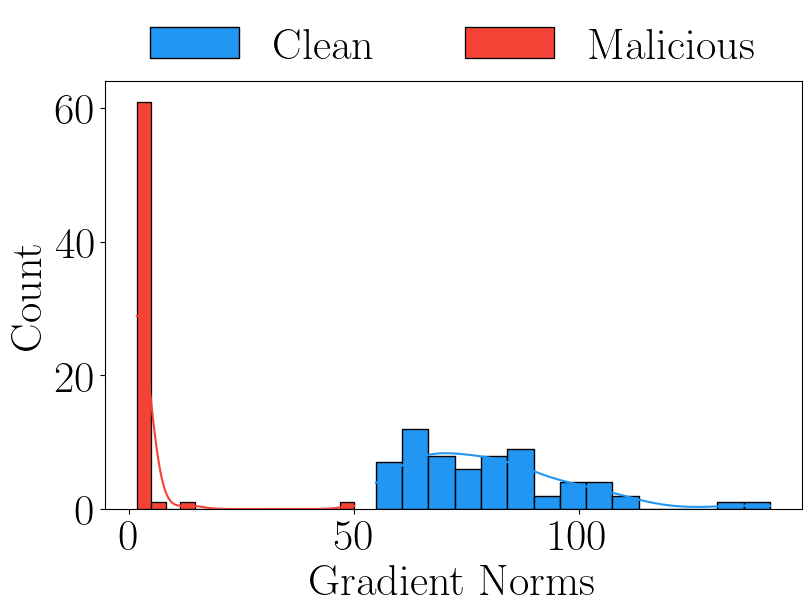

In [3]:
fontsize = 32

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "legend.fontsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
})

attack_prop = 'bright'
data = pickle.load(open(f'results/gradient_norms_bright.pkl', 'rb'))
reference_norms = data['reference_norms']
clean_public_norms = data['clean_public_norms']
malicious_public_norms = data['malicious_public_norms']
seen_examples = data['seen_examples']
clean_graidents = data['clean_gradients']
malicious_gradients = data['malicious_gradients']

plt.figure(figsize=(8, 6), constrained_layout=True)
sns.histplot(sorted(clean_graidents), color="#2196F3", kde=True, bins=15, alpha=1.0, label="Clean")
sns.histplot(sorted(malicious_gradients), color="#F44336", kde=True, bins=15, alpha=1.0, label="Malicious")


plt.xlabel('Gradient Norms')
plt.ylabel('Count')
plt.xticks()
plt.yticks()
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, 1.22),
    ncol=2,
    frameon=False,
)

# plt.savefig('img/kde_comparison.eps', format='eps', dpi=300)
plt.show()

## Experiment 9 (fig. 3a, fig. 3b)
please run exp/experiment_9.py to generate the pickle files.

In [ ]:
import numpy as np
import pandas as pd
import pickle

with open("results/experiment_9_results_green.pkl", 'rb') as f:
    results = pickle.load(f)

granite_plus_df = []
for i, epoch in results['granite_plus_clean_model'].items():
    mal_mean, mal_std = np.mean(results['granite_plus_malicious_cvs']), np.std(results['granite_plus_malicious_cvs'])
    clean_mean, clean_std = np.mean(epoch), np.std(epoch)
    if i == 0:
        ref_mean, ref_std = np.mean(results['granite_plus_ref_cvs_ep0']), np.std(results['granite_plus_ref_cvs_ep0'])
    else:
        ref_mean, ref_std = np.mean(results['granite_plus_ref_cvs']), np.std(results['granite_plus_ref_cvs'])

    
    granite_plus_df.append({
        'Epoch': i,
        'Model': 'Clean Global Model',
        'Mean': clean_mean,
        'Std': clean_std,
    })
    
    granite_plus_df.append({
        'Epoch': i,
        'Model': 'Malicious Global Model',
        'Mean': mal_mean,
        'Std': mal_std,
    })
    
    granite_plus_df.append({
        'Epoch': i,
        'Model': 'Reference Model',
        'Mean': ref_mean,
        'Std': ref_std,
    })
    
granite_plus_df = pd.DataFrame(granite_plus_df)
granite_plus_df

import numpy as np
import pandas as pd


granite_df = []
for i, epoch in results['granite_clean_model'].items():
    mal_mean, mal_std = np.mean(results['granite_malicious_cvs']), np.std(results['granite_malicious_cvs'])
    clean_mean, clean_std = np.mean(epoch), np.std(epoch)
    if i == 0:
        ref_mean, ref_std = np.mean(results['granite_ref_cvs_ep0']), np.std(results['granite_ref_cvs_ep0'])
    else:
        ref_mean, ref_std = np.mean(results['granite_ref_cvs']), np.std(results['granite_ref_cvs'])

    
    
    granite_df.append({
        'Epoch': i,
        'Model': 'Clean Global Model',
        'Mean': clean_mean,
        'Std': clean_std,
    })
    
    granite_df.append({
        'Epoch': i,
        'Model': 'Malicious Global Model',
        'Mean': mal_mean,
        'Std': mal_std,
    })
    
    granite_df.append({
        'Epoch': i,
        'Model': 'Reference Model',
        'Mean': ref_mean,
        'Std': ref_std,
    })
    
granite_df = pd.DataFrame(granite_df)

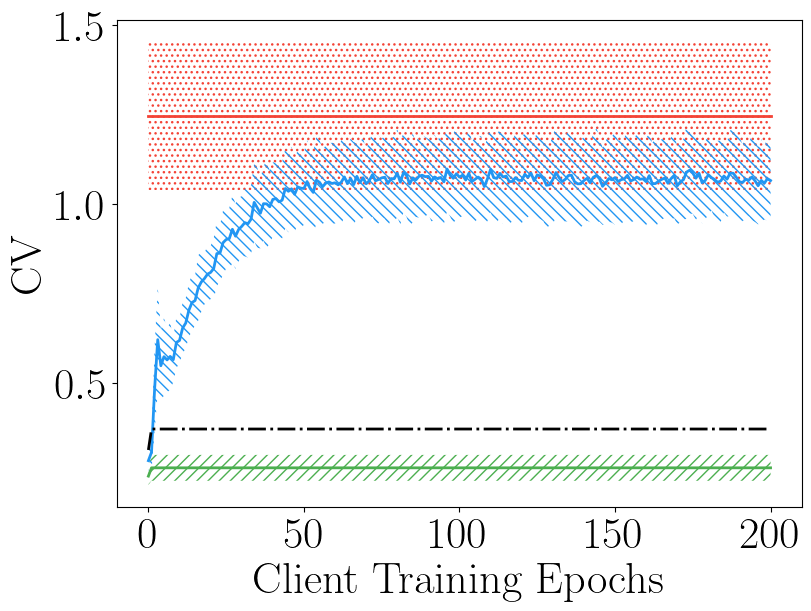

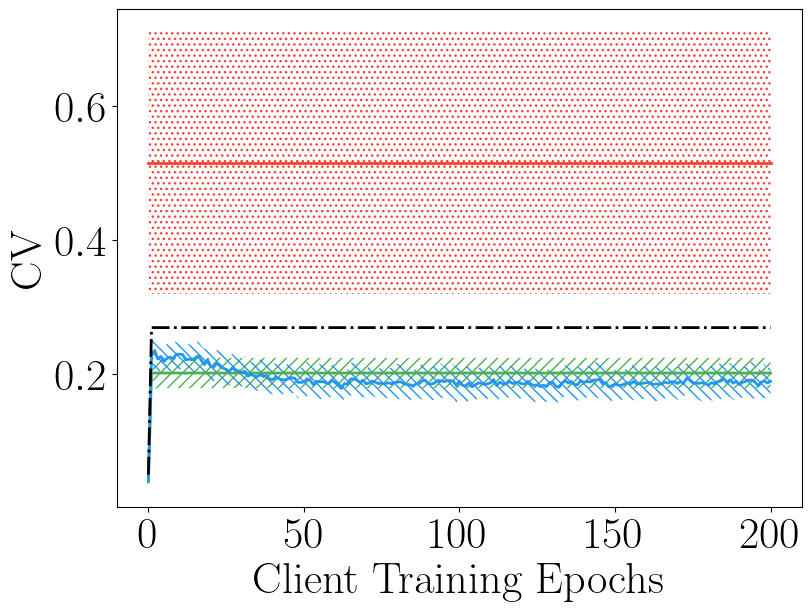

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
fontsize = 32

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "legend.fontsize": 18,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "text.latex.preamble": r"\usepackage{amsmath}",
})

loader_types = ['testloader', 'randomloader']
dfs = [granite_df, granite_plus_df] 
legend_handles = legend_labels = None

for df, loader_type in zip(dfs, loader_types):
    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    
    palette = {
        "Reference Model": "#4CAF50",
        "Malicious Global Model": "#F44336",
        "Clean Global Model": "#2196F3",
    }
    
    hatch_patterns = {
        "Reference Model": "///",
        "Malicious Global Model": "...",
        "Clean Global Model": "\\\\\\",
    }

    threshold = df.iloc[2]['Mean'] + 3 * df.iloc[2]['Std']
    
    for model, color in palette.items():
        sub = df[df["Model"] == model]
        ax.plot(sub["Epoch"], sub["Mean"], label=f"{model} Mean", color=color, linewidth=2)

        ax.fill_between(
            sub["Epoch"],
            sub["Mean"] - sub["Std"],
            sub["Mean"] + sub["Std"],
            facecolor='none',
            edgecolor=color,
            hatch=hatch_patterns.get(model, None),
            linewidth=0.0,
            label=f"{model} ±1 std",
        )
    
    sub = df[df["Model"] == "Reference Model"]
    ax.plot(sub["Epoch"], sub["Mean"] + 3 * sub["Std"], label=f"Threshold", color='black', linewidth=2, linestyle='-.')
        
    if legend_handles is None:
        handles, labels = ax.get_legend_handles_labels()
        unique = {}
        for h, l in zip(handles, labels):
            if l not in unique:
                unique[l] = h
        legend_labels = list(unique.keys())
        legend_handles = list(unique.values())

    ax.set_xlabel("Client Training Epochs")
    ax.set_ylabel("CV")
    
    ax.tick_params(axis='both', which='major')
    
    # plt.savefig(f'img/experiment_5_green_{loader_type}.eps', format='eps', dpi=300)

    plt.show()
    plt.close(fig)

legend_labels = [ 'Ref. Mean', 'Ref. ±1 std', 'Clean Mean', 'Clean ±1 std', 'Malicious Mean', 'Malicious ±1 std']


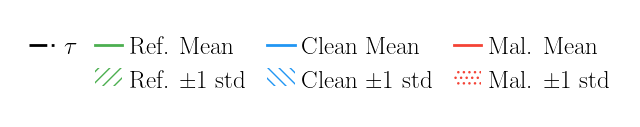

In [44]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
import matplotlib.pyplot as plt
import math

def rowmajor_to_colmajor(seq, ncol):
    m = len(seq)
    nrow = math.ceil(m / ncol)
    seq = seq + [None] * (nrow * ncol - m)
    out = []
    for c in range(ncol):
        for r in range(nrow):
            item = seq[r * ncol + c]
            if item is not None:
                out.append(item)
    return out

handles_row = [
    Line2D([0],[0], color="black", lw=2, ls="-."),                   # Threshold
    Line2D([0],[0], color="#4CAF50", lw=2),                         # Ref. Mean
    Line2D([0],[0], color="#2196F3", lw=2),                         # Clean Mean
    Line2D([0],[0], color="#F44336", lw=2),                         # Malicious Mean
    Rectangle((0,0), 0, 0, fill=False, edgecolor="none"),
    Patch(facecolor="none", edgecolor="#4CAF50", hatch="///", linewidth=0.0),     # Ref. ±1 std
    Patch(facecolor="none", edgecolor="#2196F3", hatch="\\\\\\", linewidth=0.0),  # Clean ±1 std
    Patch(facecolor="none", edgecolor="#F44336", hatch="...", linewidth=0.0),     # Malicious ±1 std
]
labels_row = [
    r"$\tau$", "Ref. Mean", "Clean Mean", "Mal. Mean", "",
    "Ref. ±1 std", "Clean ±1 std", "Mal. ±1 std",
]

ncol = 4
legend_handles = rowmajor_to_colmajor(handles_row, ncol)
legend_labels  = rowmajor_to_colmajor(labels_row,  ncol)

fig_legend, ax_legend = plt.subplots(figsize=(8, 1.4))
ax_legend.legend(
    legend_handles, legend_labels,
    loc="center",
    ncol=ncol,
    frameon=False,

    columnspacing=0.8,
    handletextpad=0.3,
    handlelength=1.1,
    handleheight=0.7,
    labelspacing=0.4,

    borderpad=0.0,
    borderaxespad=0.0,
)
ax_legend.axis("off")
# fig_legend.savefig(
#     "img/experiment_5_green_legend.eps",
#     format="eps",
#     dpi=300,
#     # pad_inches=0.02
# )
plt.show()
plt.close(fig_legend)


## Experiment 9 (fig. 4a, fig. 4b)
please run exp/experiment_9.py to generate the pickle files.

In [61]:
import numpy as np
from sklearn.metrics import f1_score
import pickle

with open("results/experiment_9_results_green.pkl", 'rb') as f:
    results = pickle.load(f)

acc_results = {}

def best_threshold_f1(pos, neg):
    X = np.concatenate([pos, neg])
    y = np.concatenate([np.ones_like(pos), np.zeros_like(neg)])

    thresholds = np.unique(X)
    if len(thresholds) > 1:
        thresholds = (thresholds[:-1] + thresholds[1:]) / 2
    else:
        thresholds = thresholds

    best_t, best_f1 = None, -1
    for t in thresholds:
        y_pred = (X >= t).astype(int)
        f1 = f1_score(y, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1

clean_acc = []
malicious_acc = []
for i, clean_cvs in results['granite_clean_model'].items():
    threshold = np.mean(results['granite_ref_cvs']) + 3 * np.std(results['granite_ref_cvs'])
    print(f'Fixed threshold: {threshold:.4f}')
    mean_clean_cv = np.mean(clean_cvs)
    mean_malicious_cv = np.mean(results['granite_malicious_cvs'])
    print(f'Clean mean CV: {mean_clean_cv:.4f}, Malicious mean CV: {mean_malicious_cv:.4f}')
    
    np.random.seed(42)
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(clean_cvs, size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
            
    print(f"clean acc: {1 - cnt / 500:.4f}")
    clean_acc.append(1 - cnt / 500)
    
    np.random.seed(42)
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(results['granite_malicious_cvs'], size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
    
    print(f"malicious acc: {cnt / 500:.4f}")
    malicious_acc.append(cnt / 500)

acc_results['granite_fixed'] = {
    'clean_acc': clean_acc,
    'malicious_acc': malicious_acc
}

clean_acc = []
malicious_acc = []

granite_f1s = []
for i, clean_cvs in results['granite_plus_clean_model'].items():
    threshold = np.mean(results['granite_plus_ref_cvs']) + 3 * np.std(results['granite_plus_ref_cvs'])
    print(f'Fixed threshold: {threshold:.4f}')
    mean_clean_cv = np.mean(clean_cvs)
    mean_malicious_cv = np.mean(results['granite_plus_malicious_cvs'])
    print(f'Clean mean CV: {mean_clean_cv:.4f}, Malicious mean CV: {mean_malicious_cv:.4f}')
    
    np.random.seed(42)
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(clean_cvs, size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
            
    print(f"clean acc: {1 - cnt / 500:.4f}")
    clean_acc.append(1 - cnt / 500)
    
    np.random.seed(42)
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(results['granite_plus_malicious_cvs'], size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
    
    print(f"malicious acc: {cnt / 500:.4f}")
    malicious_acc.append(cnt / 500)
    
acc_results['granite_plus_fixed'] = {
    'clean_acc': clean_acc,
    'malicious_acc': malicious_acc
}

clean_acc = []
malicious_acc = []


granite_f1s = []
for i, clean_cvs in results['granite_clean_model'].items():
    # threshold = np.mean(results['granite_ref_cvs']) + 3 * np.std(results['granite_ref_cvs'])
    # print(f'Fixed threshold: {threshold:.4f}')
    mean_clean_cv = np.mean(clean_cvs)
    mean_malicious_cv = np.mean(results['granite_malicious_cvs'])
    print(f'Clean mean CV: {mean_clean_cv:.4f}, Malicious mean CV: {mean_malicious_cv:.4f}')
    threshold, best_f1 = best_threshold_f1(results['granite_malicious_cvs'], clean_cvs)
    print(f'Best threshold: {threshold:.4f}')
    
    np.random.seed(42)
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(clean_cvs, size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
            
    print(f"clean acc: {1 - cnt / 500:.4f}")
    clean_acc.append(1 - cnt / 500)
    
    np.random.seed(42)
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(results['granite_malicious_cvs'], size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
    
    print(f"malicious acc: {cnt / 500:.4f}")
    malicious_acc.append(cnt / 500)
    
acc_results['granite_best'] = {
    'clean_acc': clean_acc,
    'malicious_acc': malicious_acc
}

clean_acc = []
malicious_acc = []


granite_f1s = []
for i, clean_cvs in results['granite_plus_clean_model'].items():
    # threshold = np.mean(results['granite_ref_cvs']) + 3 * np.std(results['granite_ref_cvs'])
    # print(f'Fixed threshold: {threshold:.4f}')
    mean_clean_cv = np.mean(clean_cvs)
    mean_malicious_cv = np.mean(results['granite_plus_malicious_cvs'])
    print(f'Clean mean CV: {mean_clean_cv:.4f}, Malicious mean CV: {mean_malicious_cv:.4f}')
    threshold, best_f1 = best_threshold_f1(results['granite_plus_malicious_cvs'], clean_cvs)
    print(f'Best threshold: {threshold:.4f}')
    
    np.random.seed(42)
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(clean_cvs, size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
            
    print(f"clean acc: {1 - cnt / 500:.4f}")
    clean_acc.append(1 - cnt / 500)
    
    np.random.seed(42)
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(results['granite_plus_malicious_cvs'], size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
    
    print(f"malicious acc: {cnt / 500:.4f}")
    malicious_acc.append(cnt / 500)
    
acc_results['granite_plus_best'] = {
    'clean_acc': clean_acc,
    'malicious_acc': malicious_acc
}

Fixed threshold: 0.3704
Clean mean CV: 0.2820, Malicious mean CV: 1.2456
clean acc: 1.0000
malicious acc: 1.0000
Fixed threshold: 0.3704
Clean mean CV: 0.3054, Malicious mean CV: 1.2456
clean acc: 1.0000
malicious acc: 1.0000
Fixed threshold: 0.3704
Clean mean CV: 0.4828, Malicious mean CV: 1.2456
clean acc: 0.0000
malicious acc: 1.0000
Fixed threshold: 0.3704
Clean mean CV: 0.6201, Malicious mean CV: 1.2456
clean acc: 0.0000
malicious acc: 1.0000
Fixed threshold: 0.3704
Clean mean CV: 0.5472, Malicious mean CV: 1.2456
clean acc: 0.0000
malicious acc: 1.0000
Fixed threshold: 0.3704
Clean mean CV: 0.5725, Malicious mean CV: 1.2456
clean acc: 0.0000
malicious acc: 1.0000
Fixed threshold: 0.3704
Clean mean CV: 0.5635, Malicious mean CV: 1.2456
clean acc: 0.0000
malicious acc: 1.0000
Fixed threshold: 0.3704
Clean mean CV: 0.5732, Malicious mean CV: 1.2456
clean acc: 0.0000
malicious acc: 1.0000
Fixed threshold: 0.3704
Clean mean CV: 0.5641, Malicious mean CV: 1.2456
clean acc: 0.0000
malic

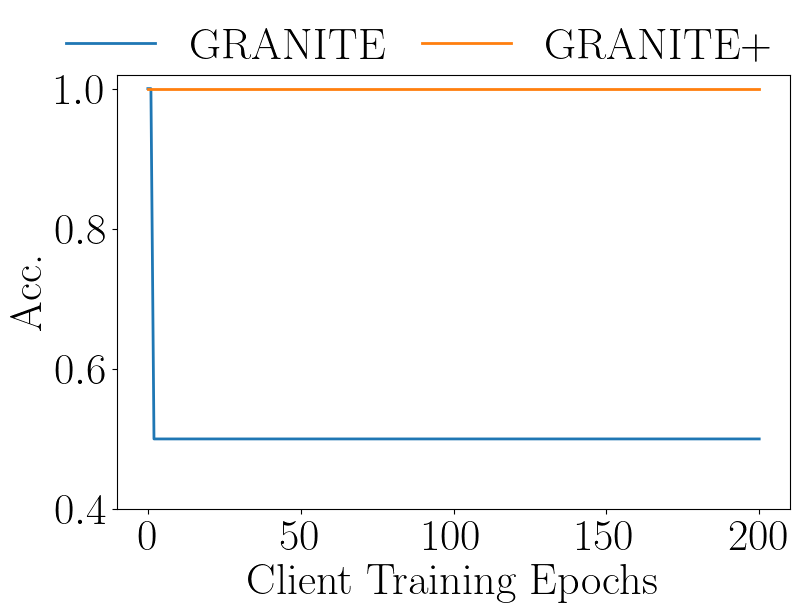

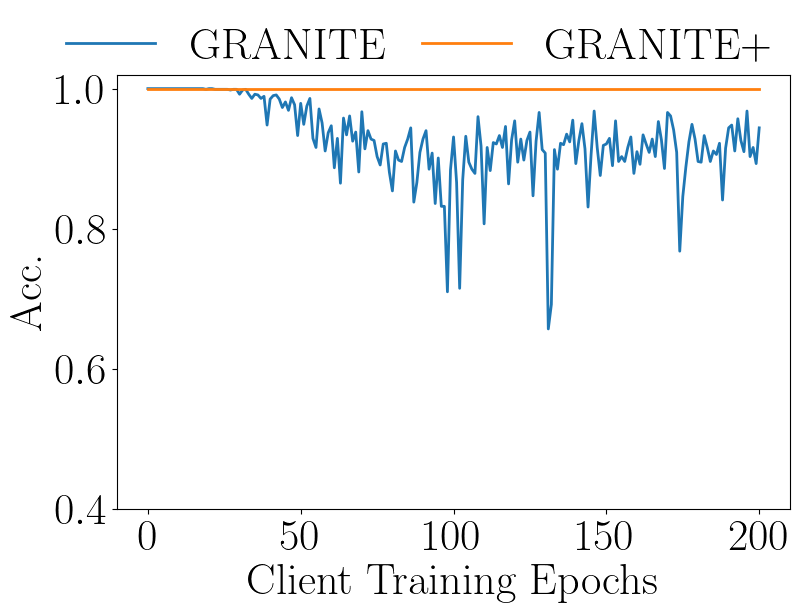

In [62]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

# with open("results/experiment_9_acc_results.pkl", 'rb') as f:
#     acc_results = pickle.load(f)

fontsize = 32

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "legend.fontsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "text.latex.preamble": r"\usepackage{amsmath}",
})

plt.figure(figsize=(8, 6), constrained_layout=True)
for key, value in acc_results.items():
    if 'fixed' in key:
        epochs = len(value['clean_acc'])
        acc = [(clean_acc + mal_acc) / 2 for clean_acc, mal_acc in zip(value['clean_acc'], value['malicious_acc'])]
        key = 'GRANITE' if 'granite_fixed' in key else 'GRANITE+'
        plt.plot(np.arange(epochs), acc, linewidth=2, markersize=5, label=f'{key}')

plt.ylim(0.4, 1.02)
# plt.title('Fixed Threshold')
plt.xlabel('Client Training Epochs')
plt.ylabel('Acc.')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.45, 1.20),
    ncol=2,
    frameon=False,
    columnspacing=0.8,
    labelspacing=0.4,
)
# plt.savefig('img/fixed_threshold_acc.eps', format='eps', dpi=300)
plt.show()


plt.figure(figsize=(8, 6), constrained_layout=True)
for key, value in acc_results.items():
    if 'fixed' not in key:
        epochs = len(value['clean_acc'])
        acc = [(clean_acc + mal_acc) / 2 for clean_acc, mal_acc in zip(value['clean_acc'], value['malicious_acc'])]
        key = 'GRANITE' if 'granite_best' in key else 'GRANITE+'
        plt.plot(np.arange(epochs), acc, linewidth=2, markersize=5, label=f'{key}')

plt.ylim(0.4, 1.02)
plt.xlabel('Client Training Epochs')
plt.ylabel('Acc.')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.45, 1.20),
    ncol=2,
    frameon=False,
    columnspacing=0.8,
    labelspacing=0.4,

)

# plt.savefig('img/best_threshold_acc.eps', format='eps', dpi=300)
plt.show()


## Experiment 11 (fig. 5a, fig. 5b, fig. 5c)
please run exp/experiment_11.py to generate the pickle files.

In [79]:
import torch
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pickle
from PIL import Image
import os
import re

with open("results/experiment_11_results.pkl", 'rb') as f:
    results = pickle.load(f)

with open("results/closest_image.pkl", 'rb') as f:
    origin_img = pickle.load(f)

origin_img = Image.fromarray((origin_img['image'].numpy().transpose(1, 2, 0) * 255).astype(np.uint8))

from PIL import Image

threshold = np.mean(results['ref_norm_cvs']) + 3 * np.std(results['ref_norm_cvs'])
print(f'Threshold: {threshold:.4f}')

ckpts = os.listdir('/trainingData/sage/alan/defence_seer/models/Cifar100/green/bs_64')
ckpts = sorted(ckpts, key=lambda x: int(re.findall(r'.(\d+)', x)[0]))

draw_results = {}

for ckpt, stat in zip(ckpts, results['per_ckpt_results'].values()):
    epoch = re.findall(r'.(\d+)', ckpt)[0]
    
    if epoch == '1':
        epoch = '0'
    
    mean_cv = np.mean(stat['malicious_norm_cvs'])
    
    cnt = 0
    detection_scores = []
    for _ in range(500):
        sampled_cvs = np.random.choice(stat['malicious_norm_cvs'], size=10, replace=False)
        mean_cv_sampled = np.mean(sampled_cvs)
        detection_scores.append(mean_cv_sampled)
        if mean_cv_sampled > threshold:
            cnt += 1
            
    detection_scores_mean = np.array(detection_scores).mean()
            
    print(f"Epoch: {epoch}, Malicious Attack Acc: {cnt / 500:.4f}")
            
    
    mean_psnr = np.mean(stat['psnrs'])
    print(f'Epoch: {epoch}, CV Mean: {mean_cv:.4f}, PSNR: {mean_psnr:.2f} dB, Above Threshold: {detection_scores_mean > threshold}')
    
    img = stat['image_outs'][2]
    img_pil = Image.fromarray((img.numpy().transpose(1, 2, 0) * 255).astype(np.uint8))
    # plt.figure(figsize=(4, 4))
    # plt.imshow(img_pil)
    # plt.axis('off')
    # plt.title(f'Epoch {epoch}, PSNR: {mean_psnr:.2f} dB')
    # plt.show()
    
    draw_results[int(epoch)] = {
        'Mean CV': mean_cv,
        'Std CV': np.std(stat['malicious_norm_cvs']),
        'Mal. Acc': cnt / 500,
        'PSNR': mean_psnr,
        'img': img_pil,
    }

Threshold: 0.3704
Epoch: 0, Malicious Attack Acc: 0.0000
Epoch: 0, CV Mean: 0.2135, PSNR: 13.87 dB, Above Threshold: False
Epoch: 25, Malicious Attack Acc: 0.0140
Epoch: 25, CV Mean: 0.3480, PSNR: 12.49 dB, Above Threshold: False
Epoch: 50, Malicious Attack Acc: 0.0000
Epoch: 50, CV Mean: 0.3180, PSNR: 14.56 dB, Above Threshold: False
Epoch: 100, Malicious Attack Acc: 0.0000
Epoch: 100, CV Mean: 0.3261, PSNR: 18.06 dB, Above Threshold: False
Epoch: 150, Malicious Attack Acc: 0.0840
Epoch: 150, CV Mean: 0.3479, PSNR: 21.46 dB, Above Threshold: False
Epoch: 200, Malicious Attack Acc: 1.0000
Epoch: 200, CV Mean: 0.4555, PSNR: 21.31 dB, Above Threshold: True
Epoch: 250, Malicious Attack Acc: 1.0000
Epoch: 250, CV Mean: 0.6045, PSNR: 22.97 dB, Above Threshold: True
Epoch: 300, Malicious Attack Acc: 1.0000
Epoch: 300, CV Mean: 0.6343, PSNR: 25.01 dB, Above Threshold: True
Epoch: 350, Malicious Attack Acc: 1.0000
Epoch: 350, CV Mean: 0.6932, PSNR: 26.55 dB, Above Threshold: True
Epoch: 400, M

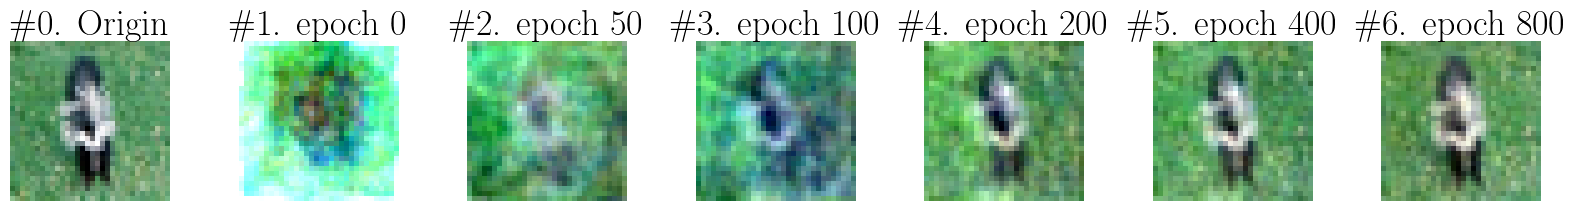

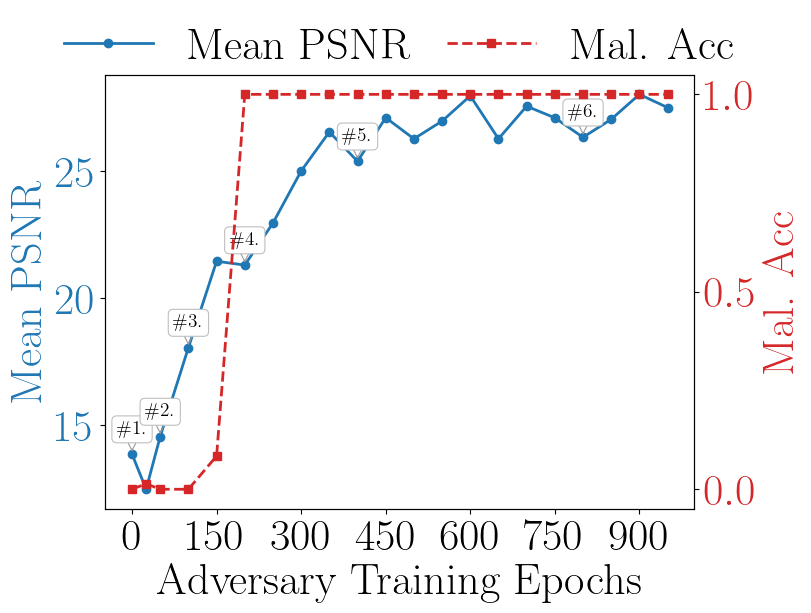

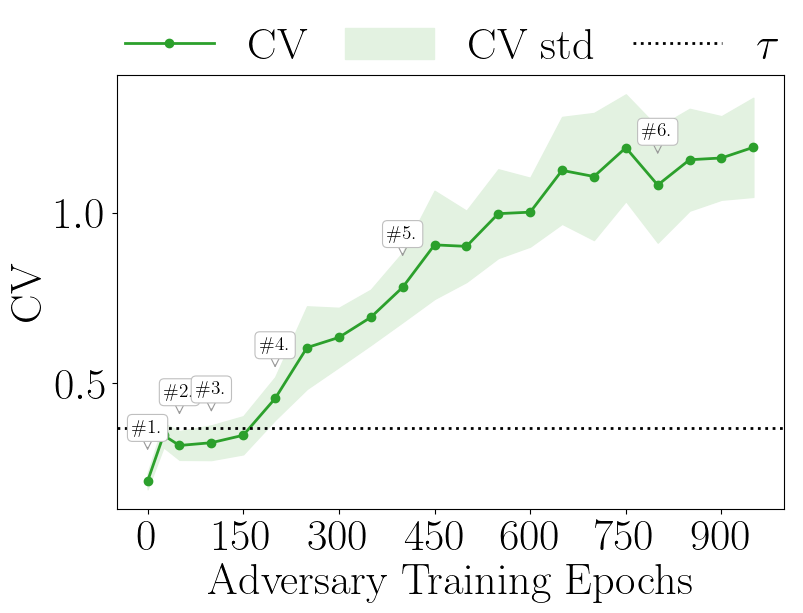

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

fontsize = 32

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "legend.fontsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "savefig.transparent": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


selected_epochs = [0, 50, 100, 200, 400, 800]
epochs = sorted(int(e) for e in draw_results.keys())
psnr_series = np.array([draw_results[e]['PSNR']      for e in epochs])
mal_series  = np.array([draw_results[e]['Mal. Acc']  for e in epochs])
mean_cv     = np.array([draw_results[e]['Mean CV']   for e in epochs])
std_cv      = np.array([draw_results[e]['Std CV']    for e in epochs])

idx_map = {e: i for i, e in enumerate(selected_epochs, start=1)}


def show_image_strip(origin_img, draw_results, selected_epochs, thumb=2.0):
    tiles, labels = [origin_img], [fr'\#0. Origin']
    for e in selected_epochs:
        if e in draw_results and 'img' in draw_results[e]:
            tiles.append(draw_results[e]['img'])
            labels.append(fr'\#{idx_map[e]}. epoch {e}')

    n = len(tiles)
    fig_w = 16
    fig_h = 2
    fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h), constrained_layout=True)
    if n == 1:
        axes = [axes]
    for ax, img, lab in zip(axes, tiles, labels):
        ax.imshow(img)
        ax.set_title(lab, fontsize=26, pad=2)
        ax.axis('off')
    # plt.savefig('img/experiment_6_image_strip.eps', format='eps', dpi=300)
    plt.show()

show_image_strip(origin_img, draw_results, selected_epochs, thumb=2.2)

def annotate_numbered_badges(ax, xs, ys, idx_map, color='#333', offset_pts=(0, 10)):
    trans = ax.transData
    for x in xs:
        if x in idx_map:
            if x in epochs:
                j = epochs.index(x)
                y = ys[j]
                ax.annotate(fr'\#{idx_map[x]}. ', xy=(x, y + 0.09), xycoords=trans,
                            xytext=offset_pts, textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=14,
                            bbox=dict(boxstyle='round,pad=0.25',
                                      facecolor='white', edgecolor='0.75', linewidth=0.8),
                            arrowprops=dict(arrowstyle='->', lw=0.8, color='0.6',
                                            shrinkA=4, shrinkB=4))

fig2, ax_left = plt.subplots(figsize=(8, 6), constrained_layout=True)
psnr_line, = ax_left.plot(epochs, psnr_series, lw=2, marker='o', color='#1f77b4', label='Mean PSNR')
ax_left.set_xlabel('Adversary Training Epochs')
ax_left.set_ylabel('Mean PSNR', color='#1f77b4')
ax_left.tick_params(axis='y', labelcolor='#1f77b4')
ax_left.xaxis.set_major_locator(MaxNLocator(integer=True))

ax_right = ax_left.twinx()
mal_line, = ax_right.plot(epochs, mal_series, lw=2, ls='--', marker='s', color='#d62728', label='Mal. Acc')
ax_right.set_ylabel('Mal. Acc', color='#d62728')
ax_right.tick_params(axis='y', labelcolor='#d62728')

lines2 = [psnr_line, mal_line]
labels2 = [l.get_label() for l in lines2]
ax_left.legend(lines2, labels2, loc='upper center', bbox_to_anchor=(0.5, 1.20),
               ncol=2, frameon=False,     columnspacing=0.8,
    labelspacing=0.4,
)

annotate_numbered_badges(ax_left, selected_epochs, psnr_series, idx_map, color='#1f77b4', offset_pts=(0, 10))

# plt.savefig('img/experiment_6_psnr_malacc.eps', format='eps', dpi=300)
plt.show()

fig3, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
band_fill = '#e3f2e1'
mean_line, = ax.plot(epochs, mean_cv, lw=2, marker='o', color='#2ca02c', label='CV')
ax.fill_between(epochs, mean_cv - std_cv, mean_cv + std_cv,
                color=band_fill, label='CV std')  # 不用 alpha
th_line = ax.axhline(0.3704, ls=':', lw=2, color='k', label=r'$\tau$')
ax.set_xlabel('Adversary Training Epochs')
ax.set_ylabel('CV')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

handles3, labels3 = ax.get_legend_handles_labels()
ax.legend(handles3, labels3, loc='upper center', bbox_to_anchor=(0.5, 1.20),
          ncol=3, frameon=False,     columnspacing=0.8,
    labelspacing=0.4,
)
annotate_numbered_badges(ax, selected_epochs, mean_cv, idx_map, color='#2ca02c', offset_pts=(0, 10))

# plt.savefig('img/experiment_6_cv.eps', format='eps', dpi=300)
plt.show()


## Experiment 2 (Table 1)
please run exp/experiment_2.py to generate the pickle files.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

with open("results/experiment_2_results.pkl", 'rb') as f:
    results = pickle.load(f)


print(f"Reference Model CVs: mean={np.mean(results['ref_norm_cvs']):.4f}, std={np.std(results['ref_norm_cvs']):.4f}")
print(f"threshold = {np.mean(results['ref_norm_cvs']) + 3 * np.std(results['ref_norm_cvs']):.4f}")
threshold = np.mean(results['ref_norm_cvs']) + 3 * np.std(results['ref_norm_cvs'])

for cvs in ['malicious_norm_cvs_bright', 'malicious_norm_cvs_green', 'malicious_norm_cvs_blue', 'malicious_norm_cvs_red', 'malicious_norm_cvs_hedge', 'malicious_norm_cvs_vedge', 'malicious_norm_cvs_rand_conv']:
    print(f"{cvs}: mean={np.mean(results[cvs]):.4f}, std={np.std(results[cvs]):.4f}")
    
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(results[cvs], size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
            
    print(f"{cvs}, Mal. acc: {cnt / 500:.4f}")
    
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(results['clean_norm_cvs'], size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
    
    print(f"{cvs}, Clean acc: {1 - cnt / 500:.4f}")

Reference Model CVs: mean=0.2619, std=0.0361
threshold = 0.3704
malicious_norm_cvs_bright: mean=2.2363, std=0.3093
malicious_norm_cvs_bright, Mal. acc: 1.0000
malicious_norm_cvs_bright, Clean acc: 1.0000
malicious_norm_cvs_green: mean=1.2635, std=0.1573
malicious_norm_cvs_green, Mal. acc: 1.0000
malicious_norm_cvs_green, Clean acc: 1.0000
malicious_norm_cvs_blue: mean=2.2384, std=0.2911
malicious_norm_cvs_blue, Mal. acc: 1.0000
malicious_norm_cvs_blue, Clean acc: 1.0000
malicious_norm_cvs_red: mean=1.8475, std=0.1988
malicious_norm_cvs_red, Mal. acc: 1.0000
malicious_norm_cvs_red, Clean acc: 1.0000
malicious_norm_cvs_hedge: mean=1.6298, std=0.1685
malicious_norm_cvs_hedge, Mal. acc: 1.0000
malicious_norm_cvs_hedge, Clean acc: 1.0000
malicious_norm_cvs_vedge: mean=1.5851, std=0.2033
malicious_norm_cvs_vedge, Mal. acc: 1.0000
malicious_norm_cvs_vedge, Clean acc: 1.0000
malicious_norm_cvs_rand_conv: mean=1.5111, std=0.1995
malicious_norm_cvs_rand_conv, Mal. acc: 1.0000
malicious_norm_cvs_

## Experiment 8 (Table 2)
please run exp/experiment_3.py to generate the pickle files.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

with open("results/experiment_3_results.pkl", 'rb') as f:
    results = pickle.load(f)

np.random.seed(42)
print(f"Reference Model CVs: mean={np.mean(results['ref_norm_cvs']):.4f}, std={np.std(results['ref_norm_cvs']):.4f}")
print(f"threshold = {np.mean(results['ref_norm_cvs']) + 3 * np.std(results['ref_norm_cvs']):.4f}")
threshold = np.mean(results['ref_norm_cvs']) + 3 * np.std(results['ref_norm_cvs'])

for cvs in ['malicious_norm_cvs_16', 'malicious_norm_cvs_32', 'malicious_norm_cvs_64']:
    print(f"{cvs}: mean={np.mean(results[cvs]):.4f}, std={np.std(results[cvs]):.4f}")
    
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(results[cvs], size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
            
    print(f"{cvs}, Mal. acc: {cnt / 500:.4f}")
    
    cnt = 0
    for _ in range(500):
        sampled_cvs = np.random.choice(results['clean_norm_cvs'], size=10, replace=False)
        mean_cv = np.mean(sampled_cvs)
        if mean_cv > threshold:
            cnt += 1
    
    print(f"{cvs}, Clean acc: {1 - cnt / 500:.4f}")

Reference Model CVs: mean=0.2253, std=0.0313
threshold = 0.3193
malicious_norm_cvs_16: mean=1.2367, std=0.1486
malicious_norm_cvs_16, Mal. acc: 1.0000
malicious_norm_cvs_16, Clean acc: 1.0000
malicious_norm_cvs_32: mean=1.7830, std=0.1786
malicious_norm_cvs_32, Mal. acc: 1.0000
malicious_norm_cvs_32, Clean acc: 1.0000
malicious_norm_cvs_64: mean=2.2363, std=0.3093
malicious_norm_cvs_64, Mal. acc: 1.0000
malicious_norm_cvs_64, Clean acc: 1.0000


## Experiment 8 (Table 3)
please run exp/run_exp8.sh to generate the pickle files.

In [2]:
import pickle
import numpy as np


# attack = 'Cifar100'
# client = 'Food101'
# loader = 'randomloader'
# prop = 'green'


for attack in ['Cifar10', 'Cifar100']:
    clients = ['Cifar100', 'TinyImageNet', 'Food101'] if attack == 'Cifar100' else ['Cifar10', 'TinyImageNet', 'Food101']
    for client in clients:
        for loader in ['randomloader', 'testloader']:
            for prop in ['green']:
                
                try:
                    with open(f"results/experiment_8-{attack}-{client}-{prop}-{loader}.pkl", 'rb') as f:
                        results = pickle.load(f)
                except:
                    continue

                ref_mean = np.mean(results['ref_cvs'])
                ref_std = np.std(results['ref_cvs'])
                threshold = ref_mean + 3 * ref_std
                clean_mean = np.mean(results['clean_cvs'])
                malicious_mean = np.mean(results['malicious_cvs'])
                psnr_mean = np.mean(results['psnrs']) if len(results['psnrs']) > 0 else 0.0
                loader_2_method = {'randomloader': 'GRANITE+', 'testloader': 'GRANITE'}[loader]
                print(f"Experiment: Attack={attack}, Client={client}, Prop={prop}, Loader={loader_2_method}")
                print(f"psnr: {psnr_mean:.2f} dB")

                seen_examples = 10

                np.random.seed(42)
                cnt = 0
                for _ in range(500):
                    sampled_cvs = np.random.choice(results['clean_cvs'], size=seen_examples, replace=False)
                    mean_cv = np.mean(sampled_cvs)
                    if mean_cv > threshold:
                        cnt += 1

                print(f"clean acc: {1 - cnt / 500:.4f}")

                cnt = 0
                for _ in range(500):
                    sampled_cvs = np.random.choice(results['malicious_cvs'], size=seen_examples, replace=False)
                    mean_cv = np.mean(sampled_cvs)
                    if mean_cv > threshold:
                        cnt += 1

                print(f"malicious acc: {cnt / 500:.4f}")

Experiment: Attack=Cifar10, Client=Cifar10, Prop=green, Loader=GRANITE+
psnr: 0.00 dB
clean acc: 1.0000
malicious acc: 1.0000
Experiment: Attack=Cifar10, Client=Cifar10, Prop=green, Loader=GRANITE
psnr: 25.76 dB
clean acc: 1.0000
malicious acc: 1.0000
Experiment: Attack=Cifar10, Client=TinyImageNet, Prop=green, Loader=GRANITE+
psnr: 0.00 dB
clean acc: 1.0000
malicious acc: 1.0000
Experiment: Attack=Cifar10, Client=TinyImageNet, Prop=green, Loader=GRANITE
psnr: 19.34 dB
clean acc: 1.0000
malicious acc: 1.0000
Experiment: Attack=Cifar10, Client=Food101, Prop=green, Loader=GRANITE+
psnr: 0.00 dB
clean acc: 1.0000
malicious acc: 1.0000
Experiment: Attack=Cifar10, Client=Food101, Prop=green, Loader=GRANITE
psnr: 22.06 dB
clean acc: 1.0000
malicious acc: 1.0000
Experiment: Attack=Cifar100, Client=Cifar100, Prop=green, Loader=GRANITE+
psnr: 0.00 dB
clean acc: 1.0000
malicious acc: 1.0000
Experiment: Attack=Cifar100, Client=Cifar100, Prop=green, Loader=GRANITE
psnr: 28.32 dB
clean acc: 1.0000
